In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.4/479.4 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pygit2 1.19.1 requires cffi>=2.0, but you have cffi 1.17.1 which is incompatible.
A processar: AC...
A processar: AM...
A processar: AP...
A processar: PA...
A processar: RO...
A processar: RO...
A processar: RR...
A processar: TO...


<Figure size 1600x1000 with 0 Axes>

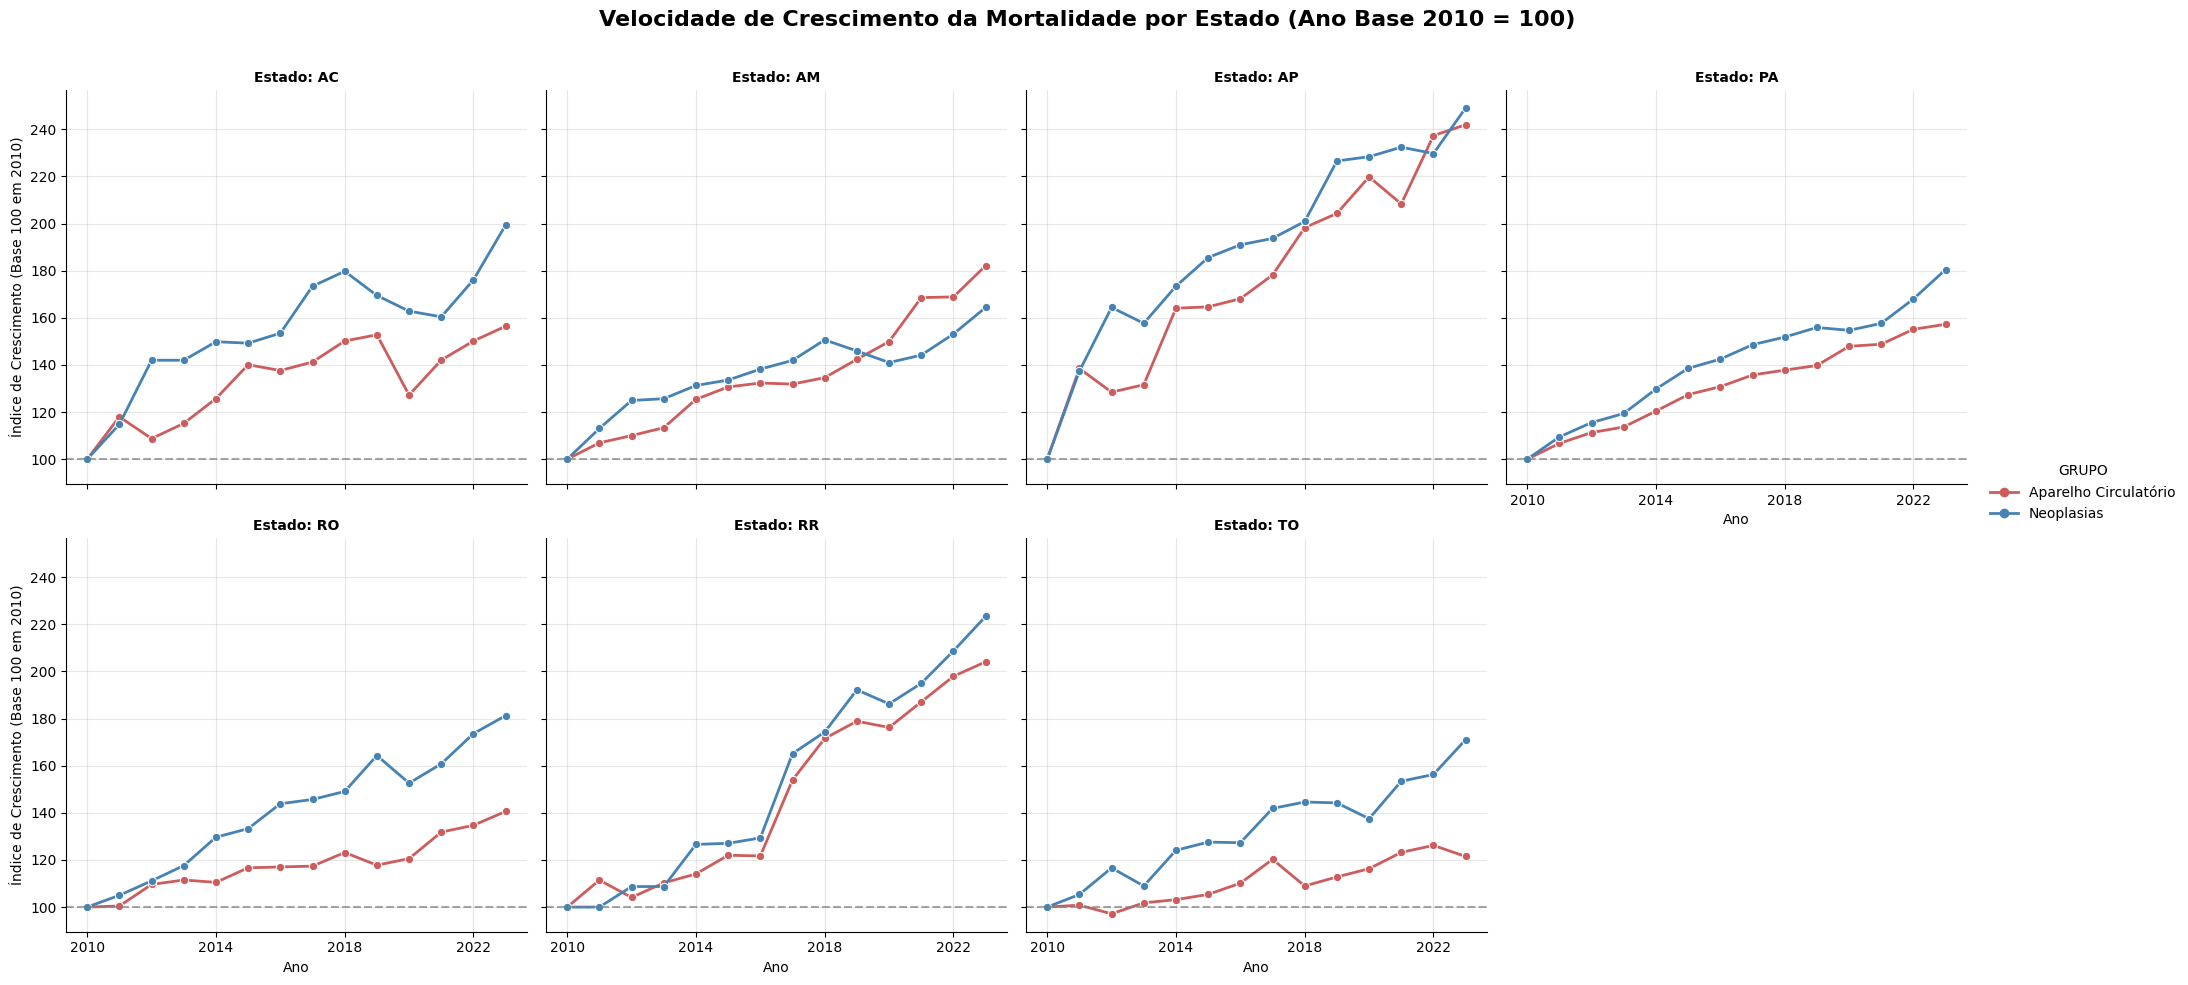


 RANKING DO CRESCIMENTO ACUMULADO (2010 vs 2023) POR ESTADO

-> Grupo: Aparelho Circulatório
   AP: cresceu 142.0% em relação a 2010 (Absoluto: 348 -> 842)
   RR: cresceu 104.1% em relação a 2010 (Absoluto: 341 -> 696)
   AM: cresceu 82.1% em relação a 2010 (Absoluto: 2378 -> 4331)
   PA: cresceu 57.3% em relação a 2010 (Absoluto: 6900 -> 10851)
   AC: cresceu 56.4% em relação a 2010 (Absoluto: 606 -> 948)
   RO: cresceu 40.6% em relação a 2010 (Absoluto: 3394 -> 4772)
   TO: cresceu 21.5% em relação a 2010 (Absoluto: 2063 -> 2506)

-> Grupo: Neoplasias
   AP: cresceu 149.1% em relação a 2010 (Absoluto: 222 -> 553)
   RR: cresceu 123.4% em relação a 2010 (Absoluto: 218 -> 487)
   AC: cresceu 99.4% em relação a 2010 (Absoluto: 331 -> 660)
   RO: cresceu 81.2% em relação a 2010 (Absoluto: 1760 -> 3190)
   PA: cresceu 80.5% em relação a 2010 (Absoluto: 3386 -> 6112)
   TO: cresceu 71.1% em relação a 2010 (Absoluto: 805 -> 1377)
   AM: cresceu 64.4% em relação a 2010 (Absoluto: 1870 -> 30

In [2]:
# 1. Instalação das bibliotecas necessárias
# No Kaggle, usamos !pip para instalar o que não vem por padrão
!pip install pyreaddbc dbfread -q

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

# 2. Configurações de Estados e Anos
# Adicionei os estados que você solicitou
ESTADOS = [
  "AC",
  "AM",
  "AP",
  "PA",
  "RO",
  "RO",
  "RR",
  "TO"
] 
ANOS = range(2010, 2024)

# No Kaggle, usamos o diretório /kaggle/working/ para salvar ficheiros
pasta_base = Path("/kaggle/working/dados_sus")
pasta_base.mkdir(exist_ok=True)

# 3. Funções de Apoio
def baixar_arquivo(url, destino):
    if destino.exists(): return True
    try:
        urlretrieve(url, destino)
        return True
    except:
        return False

def ler_e_limpar_dbc(caminho_dbc):
    """Converte DBC para DBF, lê e apaga o DBF para poupar espaço"""
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))
        if caminho_dbf.exists(): os.remove(caminho_dbf)
        return df
    except:
        return None

def filtrar_causas(causa):
    if pd.isna(causa): return "Outros"
    c = str(causa).upper()
    if c.startswith('C') or (c.startswith('D') and '00' <= c[1:3] <= '48'):
        return "Neoplasias"
    if c.startswith('I'):
        return "Aparelho Circulatório"
    return "Outros"

# 4. Processamento Principal
resultados = []

for uf in ESTADOS:
    print(f"A processar: {uf}...")
    for ano in ANOS:
        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho_dbc = pasta_base / nome
        
        if baixar_arquivo(url, caminho_dbc):
            df_temp = ler_e_limpar_dbc(caminho_dbc)
            if df_temp is not None:
                df_temp["GRUPO"] = df_temp["CAUSABAS"].apply(filtrar_causas)
                # Agrupamos aqui para não sobrecarregar a memória RAM do Kaggle
                resumo = df_temp[df_temp["GRUPO"] != "Outros"].groupby(["GRUPO"]).size().reset_index(name="OBITOS")
                resumo["UF"] = uf
                resumo["ANO"] = ano
                resultados.append(resumo)
                # Opcional: remover o .dbc original para economizar disco
                # os.remove(caminho_dbc)

# 5. Consolidação e Gráfico
# ==============================================================================
# 5. CONSOLIDAÇÃO, NORMALIZAÇÃO E ANÁLISE COMPLEMENTAR DE CRESCIMENTO
# ==============================================================================
if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
    df_final.to_csv("mortalidade_norte_consolidado.csv", index=False)

    # --------------------------------------------------------------------------
    # PASSO 1: Criar a métrica de Crescimento Relativo (Base 100 em 2010)
    # Isso remove o viés do tamanho da população de cada estado.
    # --------------------------------------------------------------------------
    # Garantir que não há duplicatas de UF/ANO/GRUPO acumuladas por erro de lista
    df_f = df_final.groupby(["UF", "ANO", "GRUPO"])["OBITOS"].sum().reset_index()
    
    # Encontrar o valor de referência (Ano 2010) para cada UF e cada GRUPO
    df_2010 = df_f[df_f["ANO"] == 2010][["UF", "GRUPO", "OBITOS"]].rename(columns={"OBITOS": "OBITOS_2010"})
    
    # Mesclar e calcular o índice (Valor do Ano / Valor de 2010) * 100
    df_ind = pd.merge(df_f, df_2010, on=["UF", "GRUPO"], how="left")
    df_ind["INDICE_CRESCIMENTO"] = (df_ind["OBITOS"] / df_ind["OBITOS_2010"]) * 100

    # --------------------------------------------------------------------------
    # PASSO 2: Visualização 1 - O Comportamento por Estado (Lado a Lado)
    # Permite ver se a tendência de aceleração é homogênea ou se há outliers.
    # --------------------------------------------------------------------------
    plt.figure(figsize=(16, 10))
    g = sns.relplot(
        data=df_ind,
        x="ANO", 
        y="INDICE_CRESCIMENTO", 
        hue="GRUPO", 
        col="UF", 
        col_wrap=4, # Organiza em uma grade de 4 colunas
        kind="line", 
        marker="o", 
        linewidth=2,
        palette=["#CD5C5C", "#4682B4"]
    )
    
    g.set_titles("Estado: {col_name}", fontweight='bold')
    g.set_axis_labels("Ano", "Índice de Crescimento (Base 100 em 2010)")
    
    # Adiciona a linha horizontal de referência (100 = nível de 2010)
    for ax in g.axes.flat:
        ax.axhline(100, color="gray", linestyle="--", alpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([2010, 2014, 2018, 2022])
        
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("Velocidade de Crescimento da Mortalidade por Estado (Ano Base 2010 = 100)", fontsize=16, fontweight='bold')
    plt.show()

    # --------------------------------------------------------------------------
    # PASSO 3: Identificação de Outliers e Assimetrias (Quem cresceu mais?)
    # --------------------------------------------------------------------------
    print("\n" + "="*80)
    print(" RANKING DO CRESCIMENTO ACUMULADO (2010 vs 2023) POR ESTADO")
    print("="*80)
    
    df_2023 = df_ind[df_ind["ANO"] == 2023].copy()
    df_2023["VARIACAO_PERC"] = df_2023["INDICE_CRESCIMENTO"] - 100
    
    ranking = df_2023.sort_values(by=["GRUPO", "VARIACAO_PERC"], ascending=[True, False])
    for grupo in ranking["GRUPO"].unique():
        print(f"\n-> Grupo: {grupo}")
        df_g = ranking[ranking["GRUPO"] == grupo]
        for _, row in df_g.iterrows():
            print(f"   {row['UF']}: cresceu {row['VARIACAO_PERC']:.1f}% em relação a 2010 (Absoluto: {row['OBITOS_2010']} -> {row['OBITOS']})")

else:
    print("Nenhum dado processado.")

A processar: ES...
A processar: MG...
A processar: RJ...
A processar: SP...


<Figure size 1600x1000 with 0 Axes>

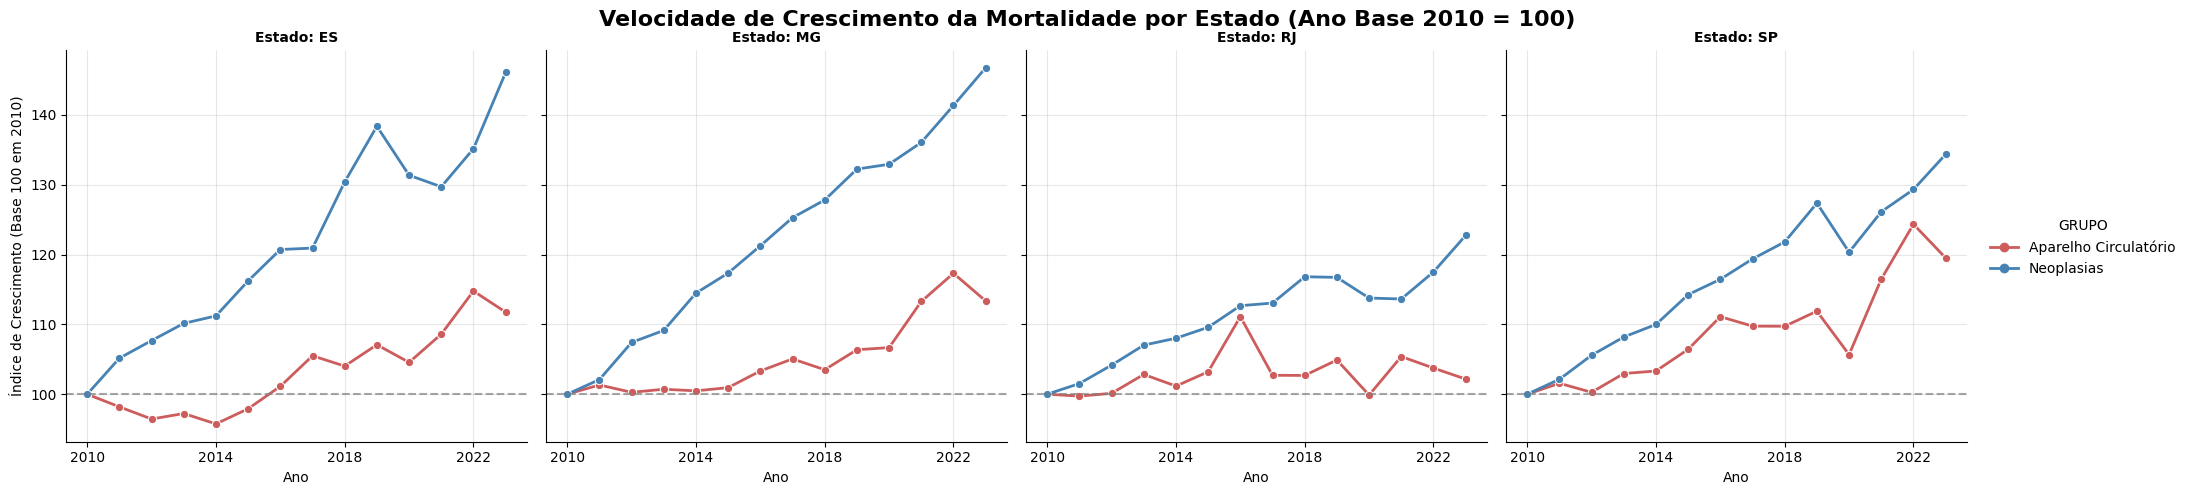


 RANKING DO CRESCIMENTO ACUMULADO (2010 vs 2023) POR ESTADO

-> Grupo: Aparelho Circulatório
   SP: cresceu 19.5% em relação a 2010 (Absoluto: 79933 -> 95538)
   MG: cresceu 13.4% em relação a 2010 (Absoluto: 33368 -> 37828)
   ES: cresceu 11.8% em relação a 2010 (Absoluto: 6580 -> 7354)
   RJ: cresceu 2.2% em relação a 2010 (Absoluto: 37120 -> 37926)

-> Grupo: Neoplasias
   MG: cresceu 46.8% em relação a 2010 (Absoluto: 18545 -> 27215)
   ES: cresceu 46.1% em relação a 2010 (Absoluto: 3450 -> 5040)
   SP: cresceu 34.4% em relação a 2010 (Absoluto: 46288 -> 62192)
   RJ: cresceu 22.7% em relação a 2010 (Absoluto: 19408 -> 23821)


In [3]:
# 1. Instalação das bibliotecas necessárias
# No Kaggle, usamos !pip para instalar o que não vem por padrão
!pip install pyreaddbc dbfread -q

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

# 2. Configurações de Estados e Anos
# Adicionei os estados que você solicitou
ESTADOS = [
  "ES",
  "MG",
  "RJ",
  "SP"
] 
ANOS = range(2010, 2024)

# No Kaggle, usamos o diretório /kaggle/working/ para salvar ficheiros
pasta_base = Path("/kaggle/working/dados_sus")
pasta_base.mkdir(exist_ok=True)

# 3. Funções de Apoio
def baixar_arquivo(url, destino):
    if destino.exists(): return True
    try:
        urlretrieve(url, destino)
        return True
    except:
        return False

def ler_e_limpar_dbc(caminho_dbc):
    """Converte DBC para DBF, lê e apaga o DBF para poupar espaço"""
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))
        if caminho_dbf.exists(): os.remove(caminho_dbf)
        return df
    except:
        return None

def filtrar_causas(causa):
    if pd.isna(causa): return "Outros"
    c = str(causa).upper()
    if c.startswith('C') or (c.startswith('D') and '00' <= c[1:3] <= '48'):
        return "Neoplasias"
    if c.startswith('I'):
        return "Aparelho Circulatório"
    return "Outros"

# 4. Processamento Principal
resultados = []

for uf in ESTADOS:
    print(f"A processar: {uf}...")
    for ano in ANOS:
        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho_dbc = pasta_base / nome
        
        if baixar_arquivo(url, caminho_dbc):
            df_temp = ler_e_limpar_dbc(caminho_dbc)
            if df_temp is not None:
                df_temp["GRUPO"] = df_temp["CAUSABAS"].apply(filtrar_causas)
                # Agrupamos aqui para não sobrecarregar a memória RAM do Kaggle
                resumo = df_temp[df_temp["GRUPO"] != "Outros"].groupby(["GRUPO"]).size().reset_index(name="OBITOS")
                resumo["UF"] = uf
                resumo["ANO"] = ano
                resultados.append(resumo)
                # Opcional: remover o .dbc original para economizar disco
                # os.remove(caminho_dbc)

# 5. Consolidação e Gráfico
# ==============================================================================
# 5. CONSOLIDAÇÃO, NORMALIZAÇÃO E ANÁLISE COMPLEMENTAR DE CRESCIMENTO
# ==============================================================================
if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
    df_final.to_csv("mortalidade_norte_consolidado.csv", index=False)

    # --------------------------------------------------------------------------
    # PASSO 1: Criar a métrica de Crescimento Relativo (Base 100 em 2010)
    # Isso remove o viés do tamanho da população de cada estado.
    # --------------------------------------------------------------------------
    # Garantir que não há duplicatas de UF/ANO/GRUPO acumuladas por erro de lista
    df_f = df_final.groupby(["UF", "ANO", "GRUPO"])["OBITOS"].sum().reset_index()
    
    # Encontrar o valor de referência (Ano 2010) para cada UF e cada GRUPO
    df_2010 = df_f[df_f["ANO"] == 2010][["UF", "GRUPO", "OBITOS"]].rename(columns={"OBITOS": "OBITOS_2010"})
    
    # Mesclar e calcular o índice (Valor do Ano / Valor de 2010) * 100
    df_ind = pd.merge(df_f, df_2010, on=["UF", "GRUPO"], how="left")
    df_ind["INDICE_CRESCIMENTO"] = (df_ind["OBITOS"] / df_ind["OBITOS_2010"]) * 100

    # --------------------------------------------------------------------------
    # PASSO 2: Visualização 1 - O Comportamento por Estado (Lado a Lado)
    # Permite ver se a tendência de aceleração é homogênea ou se há outliers.
    # --------------------------------------------------------------------------
    plt.figure(figsize=(16, 10))
    g = sns.relplot(
        data=df_ind,
        x="ANO", 
        y="INDICE_CRESCIMENTO", 
        hue="GRUPO", 
        col="UF", 
        col_wrap=4, # Organiza em uma grade de 4 colunas
        kind="line", 
        marker="o", 
        linewidth=2,
        palette=["#CD5C5C", "#4682B4"]
    )
    
    g.set_titles("Estado: {col_name}", fontweight='bold')
    g.set_axis_labels("Ano", "Índice de Crescimento (Base 100 em 2010)")
    
    # Adiciona a linha horizontal de referência (100 = nível de 2010)
    for ax in g.axes.flat:
        ax.axhline(100, color="gray", linestyle="--", alpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([2010, 2014, 2018, 2022])
        
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("Velocidade de Crescimento da Mortalidade por Estado (Ano Base 2010 = 100)", fontsize=16, fontweight='bold')
    plt.show()

    # --------------------------------------------------------------------------
    # PASSO 3: Identificação de Outliers e Assimetrias (Quem cresceu mais?)
    # --------------------------------------------------------------------------
    print("\n" + "="*80)
    print(" RANKING DO CRESCIMENTO ACUMULADO (2010 vs 2023) POR ESTADO")
    print("="*80)
    
    df_2023 = df_ind[df_ind["ANO"] == 2023].copy()
    df_2023["VARIACAO_PERC"] = df_2023["INDICE_CRESCIMENTO"] - 100
    
    ranking = df_2023.sort_values(by=["GRUPO", "VARIACAO_PERC"], ascending=[True, False])
    for grupo in ranking["GRUPO"].unique():
        print(f"\n-> Grupo: {grupo}")
        df_g = ranking[ranking["GRUPO"] == grupo]
        for _, row in df_g.iterrows():
            print(f"   {row['UF']}: cresceu {row['VARIACAO_PERC']:.1f}% em relação a 2010 (Absoluto: {row['OBITOS_2010']} -> {row['OBITOS']})")

else:
    print("Nenhum dado processado.")